In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Step 1: Import Libraries

In [2]:
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [3]:

from IPython.display import display, HTML

html_content = """
<div style="
    font-family: Arial, sans-serif;
    max-width: 850px;
    padding: 20px;
    border-radius: 12px;
    border: 1px solid #dcdcdc;
    background-color: #f8fafc;
    box-shadow: 0 2px 8px rgba(0,0,0,0.08);
">

    <h2 style="color:#1e3a8a; margin-top:0;">
        VGG16 Inference Preprocessing Pipeline
    </h2>

    <p style="color:#444;">
        <strong>Transform:</strong> 
        <code>VGG16_Weights.IMAGENET1K_V1.transforms</code>
    </p>

    <h3 style="color:#2563eb;">Supported Input Types</h3>
    <ul>
        <li>PIL.Image</li>
        <li>Batched Tensor: <code>(B, C, H, W)</code></li>
        <li>Single Image Tensor: <code>(C, H, W)</code></li>
    </ul>

    <h3 style="color:#2563eb;">Preprocessing Steps</h3>

    <table style="
        width:100%;
        border-collapse:collapse;
        background:white;
    ">
        <tr style="background:#e0e7ff;">
            <th style="padding:10px; border:1px solid #ddd;">Step</th>
            <th style="padding:10px; border:1px solid #ddd;">Operation</th>
        </tr>

        <tr>
            <td style="padding:10px; border:1px solid #ddd;">1</td>
            <td style="padding:10px; border:1px solid #ddd;">
                Resize image to <strong>256 × 256</strong>
                using <strong>Bilinear Interpolation</strong>
            </td>
        </tr>

        <tr>
            <td style="padding:10px; border:1px solid #ddd;">2</td>
            <td style="padding:10px; border:1px solid #ddd;">
                Apply <strong>Center Crop</strong> to
                <strong>224 × 224</strong>
            </td>
        </tr>

        <tr>
            <td style="padding:10px; border:1px solid #ddd;">3</td>
            <td style="padding:10px; border:1px solid #ddd;">
                Rescale pixel values to
                <strong>[0.0, 1.0]</strong>
            </td>
        </tr>

        <tr>
            <td style="padding:10px; border:1px solid #ddd;">4</td>
            <td style="padding:10px; border:1px solid #ddd;">
                Normalize using ImageNet statistics
            </td>
        </tr>
    </table>

    <h3 style="color:#2563eb; margin-top:20px;">
        Normalization Parameters
    </h3>

    <div style="
        background:#eef4ff;
        padding:12px;
        border-radius:8px;
        font-family:monospace;
    ">
        Mean = [0.485, 0.456, 0.406] <br>
        Std&nbsp;&nbsp; = [0.229, 0.224, 0.225]
    </div>

</div>
"""

display(HTML(html_content))

Step,Operation
1,Resize image to 256 × 256 using Bilinear Interpolation
2,Apply Center Crop to 224 × 224
3,"Rescale pixel values to [0.0, 1.0]"
4,Normalize using ImageNet statistics


# Step 2: Dataset Structure

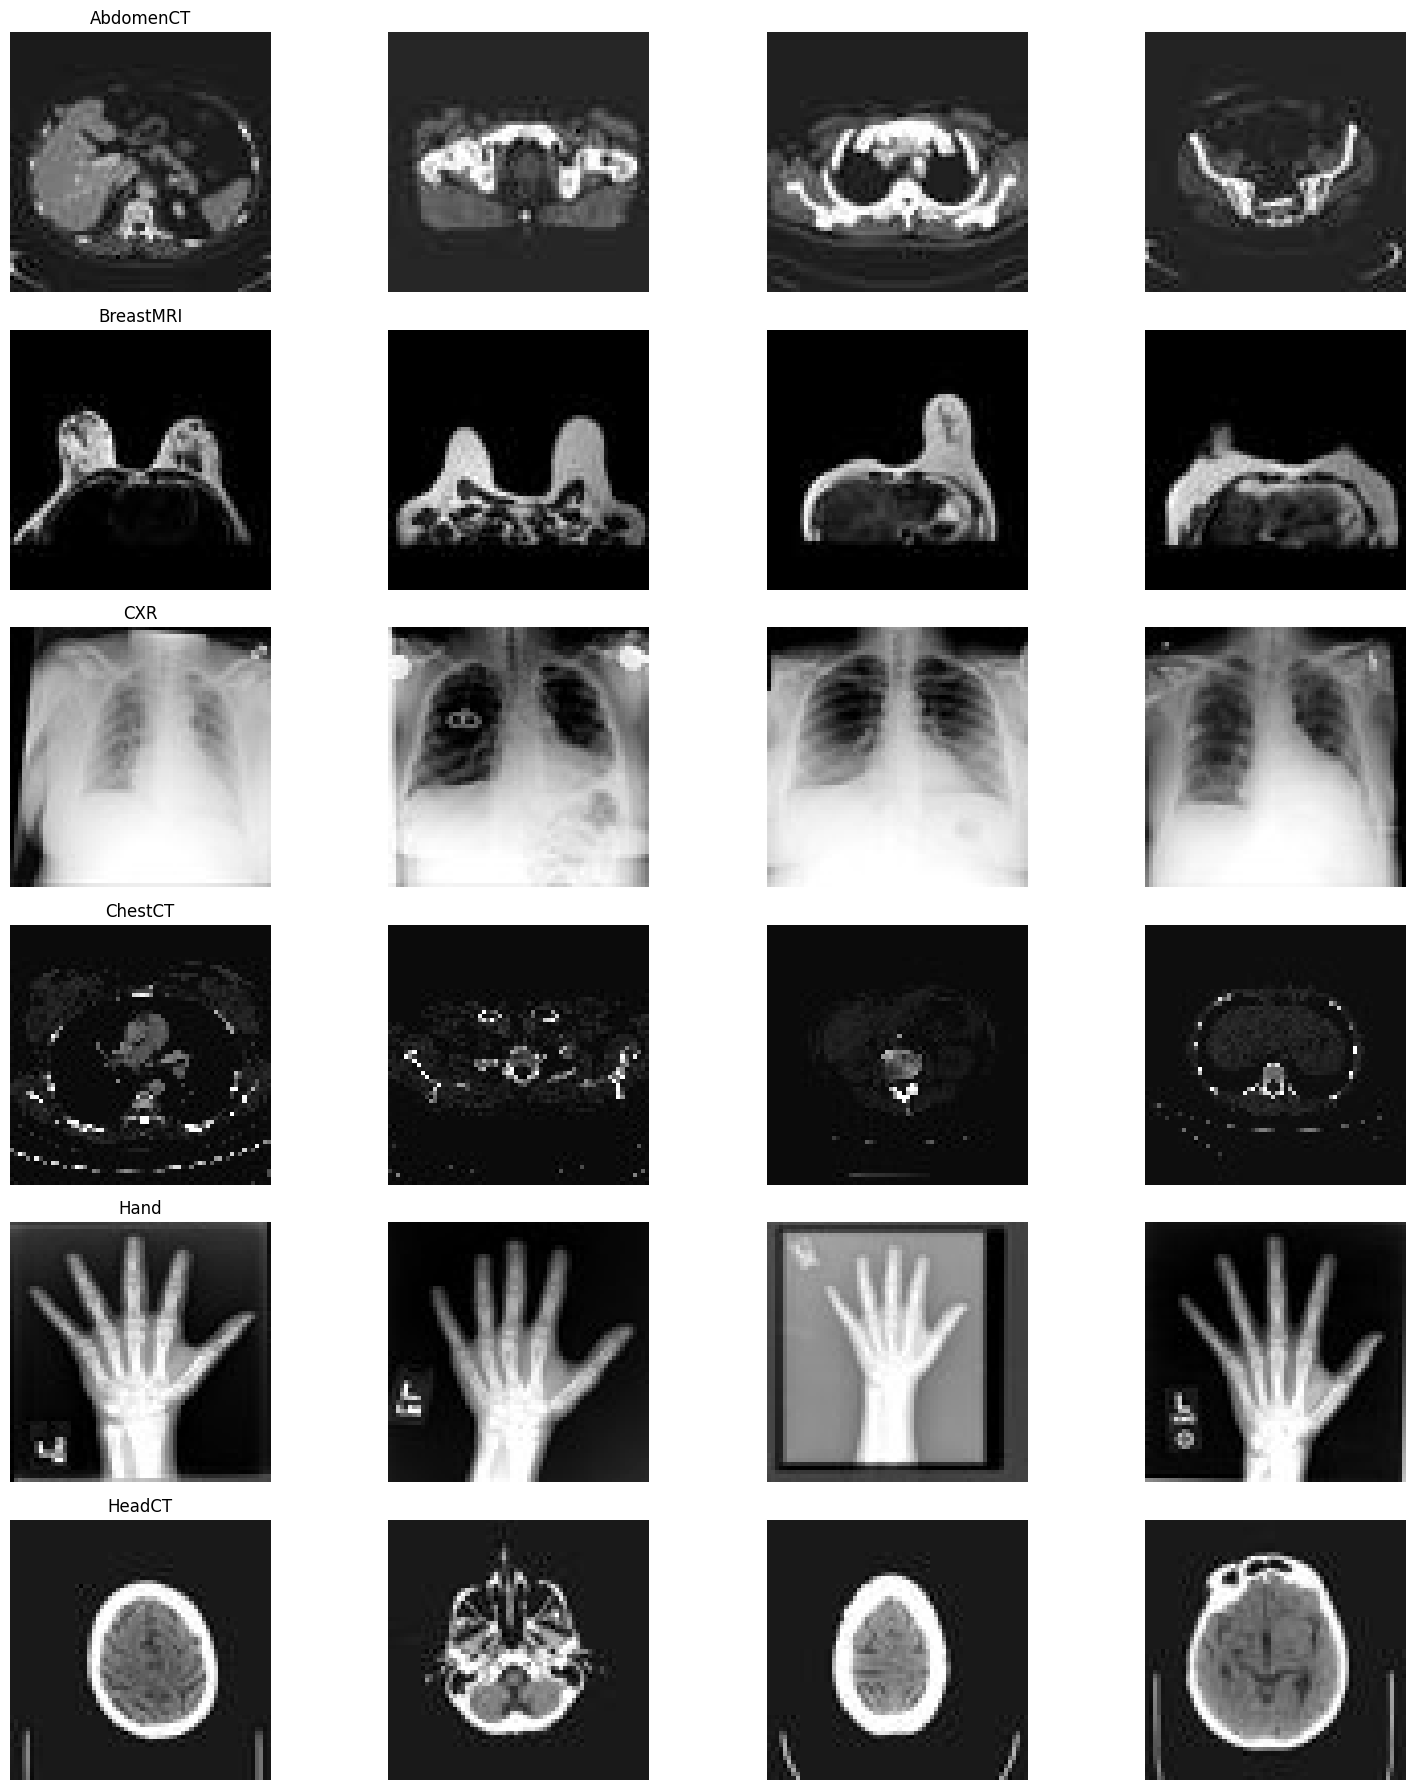

In [4]:
import os
import random
import matplotlib.pyplot as plt

def show_samples(base_path, samples_per_class=4):

    class_dirs = sorted([
        d for d in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, d))
    ])

    n_classes = len(class_dirs)

    fig, axes = plt.subplots(
        n_classes,
        samples_per_class,
        figsize=(4 * samples_per_class, 3 * n_classes)
    )

    for row, class_name in enumerate(class_dirs):

        class_path = os.path.join(base_path, class_name)

        image_files = [
            f for f in os.listdir(class_path)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]

        selected_files = random.sample(
            image_files,
            min(samples_per_class, len(image_files))
        )
        for col in range(samples_per_class):

            ax = axes[row, col] if n_classes > 1 else axes[col]

        
            if col < len(selected_files):

             
                img_path = os.path.join(class_path, selected_files[col])

              
                img = plt.imread(img_path)

              
                ax.imshow(img, cmap="gray")

         
            ax.axis("off")

         
            if col == 0:
                ax.set_title(class_name, fontsize=12)

    plt.tight_layout()

    plt.show()

base_path = "/kaggle/input/datasets/andrewmvd/medical-mnist"
show_samples(base_path, samples_per_class=4)

In [5]:
# transformations
from torchvision.transforms import transforms

custom_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Step 3: Create ImageFolder Dataset

In [6]:
dataset = ImageFolder(
    root="/kaggle/input/datasets/andrewmvd/medical-mnist",
    transform=custom_transform
)

In [7]:
dataset.classes

['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']

In [8]:
dataset.class_to_idx

{'AbdomenCT': 0,
 'BreastMRI': 1,
 'CXR': 2,
 'ChestCT': 3,
 'Hand': 4,
 'HeadCT': 5}

# Step 4: Inspect One Sample


## ImageFolder:

1. Reads first image.
2. Converts it to PIL image.
3. Applies transform.
4. Returns image tensor and label.

In [9]:
image, label = dataset[0]

In [10]:
print(image.shape)

torch.Size([3, 224, 224])


# Step 5: Look at Stored Paths

In [11]:
dataset.samples[:3]

[('/kaggle/input/datasets/andrewmvd/medical-mnist/AbdomenCT/000000.jpeg', 0),
 ('/kaggle/input/datasets/andrewmvd/medical-mnist/AbdomenCT/000001.jpeg', 0),
 ('/kaggle/input/datasets/andrewmvd/medical-mnist/AbdomenCT/000002.jpeg', 0)]

In [12]:
dataset[0]

(tensor([[[-0.3883, -0.3883, -0.3883,  ..., -0.3883, -0.3883, -0.3883],
          [-0.3883, -0.3883, -0.3883,  ..., -0.3883, -0.3883, -0.3883],
          [-0.3883, -0.3883, -0.3883,  ..., -0.3883, -0.3883, -0.3883],
          ...,
          [-0.3883, -0.3883, -0.3883,  ..., -0.3883, -0.3883, -0.3883],
          [-0.3883, -0.3883, -0.3883,  ..., -0.3883, -0.3883, -0.3883],
          [-0.3883, -0.3883, -0.3883,  ..., -0.3883, -0.3883, -0.3883]],
 
         [[-0.2675, -0.2675, -0.2675,  ..., -0.2675, -0.2675, -0.2675],
          [-0.2675, -0.2675, -0.2675,  ..., -0.2675, -0.2675, -0.2675],
          [-0.2675, -0.2675, -0.2675,  ..., -0.2675, -0.2675, -0.2675],
          ...,
          [-0.2675, -0.2675, -0.2675,  ..., -0.2675, -0.2675, -0.2675],
          [-0.2675, -0.2675, -0.2675,  ..., -0.2675, -0.2675, -0.2675],
          [-0.2675, -0.2675, -0.2675,  ..., -0.2675, -0.2675, -0.2675]],
 
         [[-0.0441, -0.0441, -0.0441,  ..., -0.0441, -0.0441, -0.0441],
          [-0.0441, -0.0441,

In [13]:
dataset.classes

['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']

In [14]:
image, label = dataset[0]

print(type(image))
print(image.shape)
print(label)

<class 'torch.Tensor'>
torch.Size([3, 224, 224])
0


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6451751..2.622571].


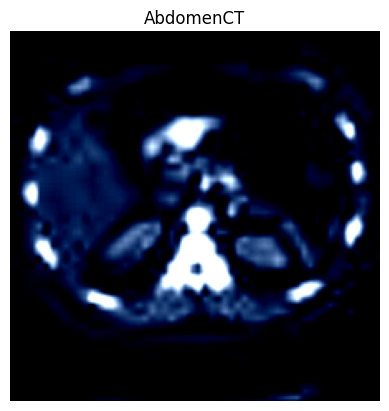

In [15]:
import matplotlib.pyplot as plt

image, label = dataset[0]

plt.imshow(image.permute(1, 2, 0))
plt.title(dataset.classes[label])
plt.axis("off")
plt.show()

# Step 6: Train-Test Split

In [16]:
train_size = int(0.75 * len(dataset))
test_size = len(dataset) - train_size

# Step 7: Perform Split

In [17]:
train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)

# Step 8: Create DataLoaders

In [18]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True,pin_memory=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False,pin_memory= True)

In [19]:
images, labels = next(iter(train_loader))

print(type(labels))
print(labels.dtype)

<class 'torch.Tensor'>
torch.int64


# Step 9: fetch the pretrained model

In [20]:
import torchvision.models as models

vgg16 = models.vgg16(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [21]:
vgg16.features

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

In [22]:
vgg16.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [23]:
for param in vgg16.features.parameters():
  param.requires_grad=False

In [24]:
num_classes = len(dataset.classes)
print(num_classes)

6


In [25]:
vgg16.classifier = nn.Sequential(
    nn.Linear(25088, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 6)
)

In [26]:
# Set random seeds for reproducibility
torch.manual_seed(42)
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [27]:
vgg16 = vgg16.to(device)

In [28]:
learning_rate = 0.0001
epochs = 3

In [29]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg16.classifier.parameters(), lr=learning_rate)

In [ ]:
for epoch in range(epochs):
    

  total_epoch_loss = 0
  vgg16.train()  
    
  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    # forward pass
    outputs = vgg16(batch_features)

    # print(outputs.shape)
    # print(batch_labels.shape)

    # calculate loss
    loss = criterion(outputs, batch_labels)

    # back pass
    optimizer.zero_grad()
    loss.backward()

    # update grads
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')

Epoch: 1 , Loss: 0.013658345887735027


In [ ]:
vgg16.eval()

# Step 9: evaluation on test data

In [ ]:
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = vgg16(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

# Step 10: evaluation on training data

In [ ]:

total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)